In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv('/content/cleanedd.csv')

In [ ]:
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


In [ ]:
columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day",
                    "city_name",
                    "order_day_of_week",
                    "order_month"]

df.drop(columns=columns_to_drop, inplace=True)

df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,0,10.0,morning,1.489846,short
45498,21.0,4.6,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,0,15.0,evening,NaN,NaN
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,0,5.0,afternoon,6.232393,medium


In [ ]:
df.isna().sum()

,0
age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: >

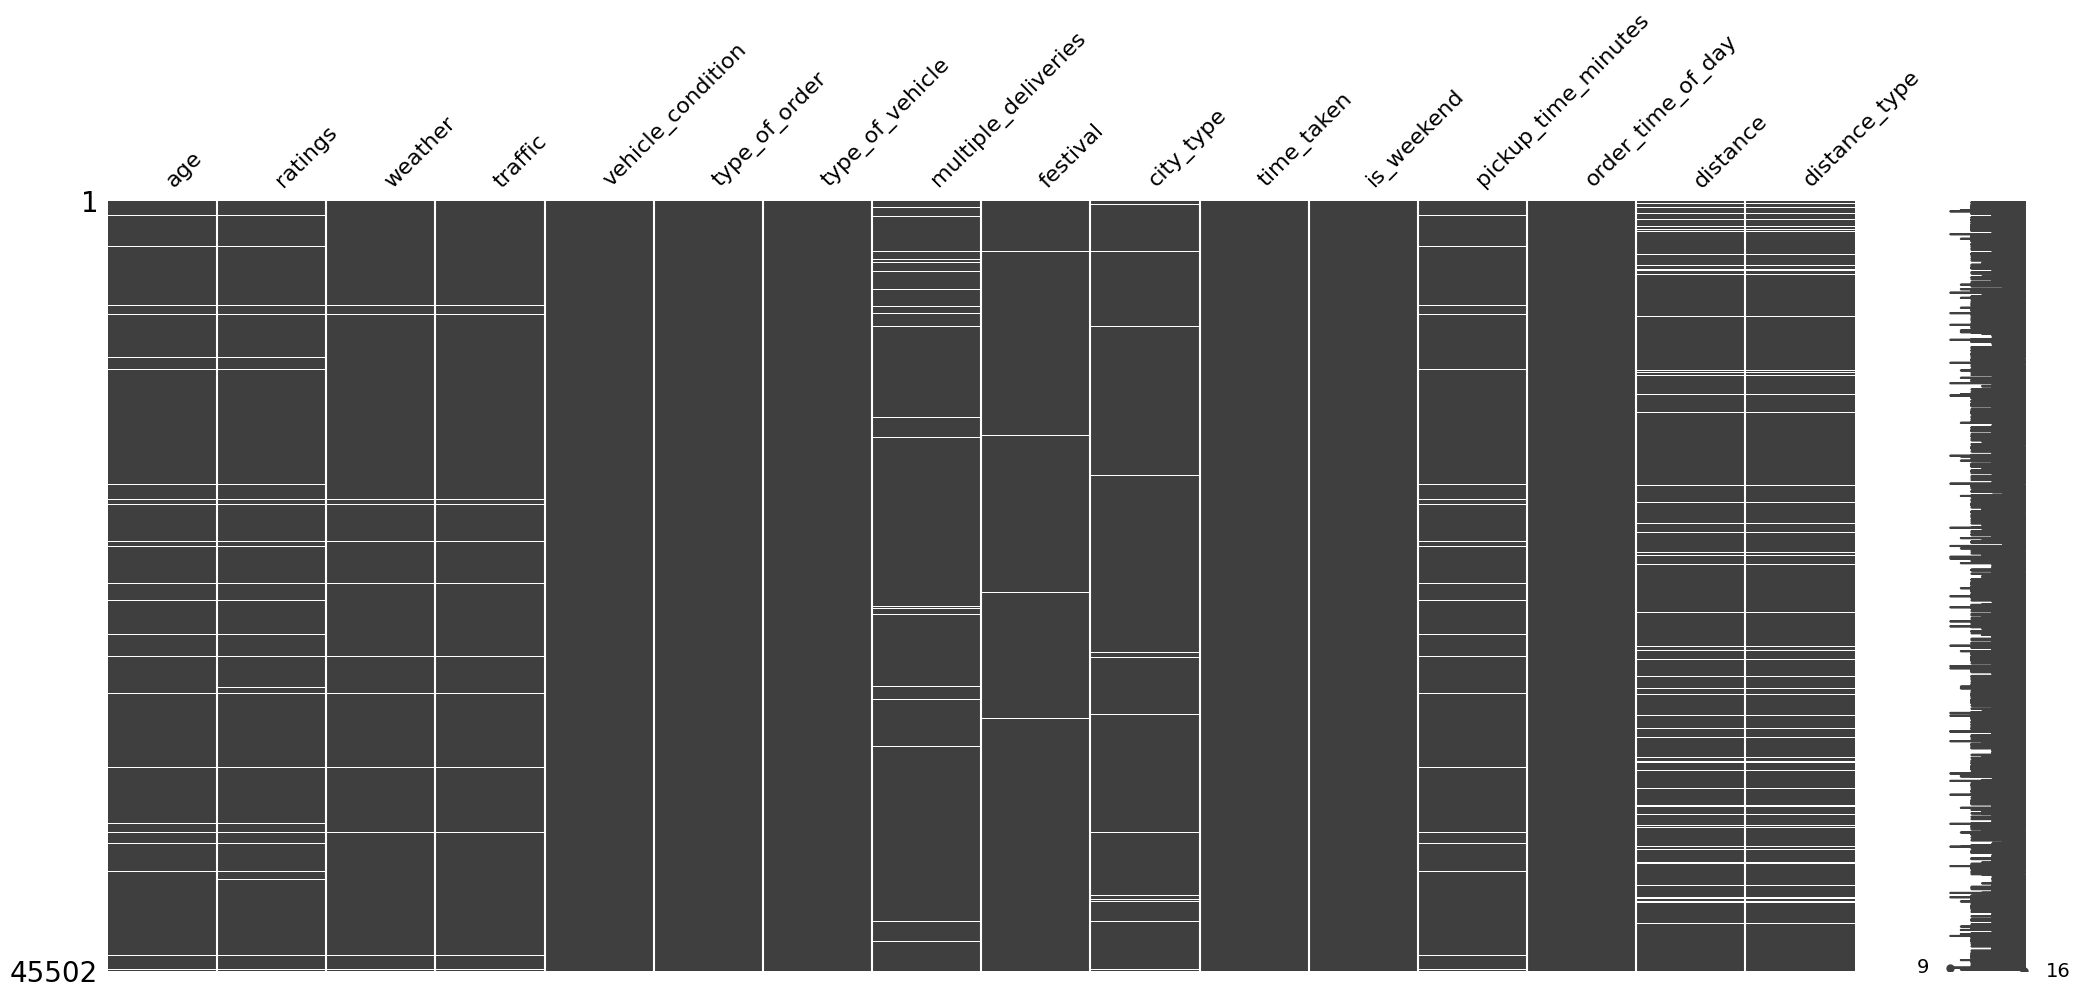

In [ ]:
import missingno as msno

msno.matrix(df)

In [ ]:
missing_cols = (
                    df
                    .isna()
                    .any(axis=0)
                    .loc[lambda x: x]
                    .index
                )

missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'distance',
       'distance_type'],
      dtype='object')

In [ ]:
temp_df = df.copy().dropna()

In [ ]:
X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45496,35.0,4.2,windy,jam,2,drinks,motorcycle,1.0,no,metropolitian,0,10.0,night,16.600272,very_long
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,0,10.0,morning,1.489846,short
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,0,5.0,afternoon,6.232393,medium


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (30451, 15)
The shape of test data is (7613, 15)


In [ ]:
X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [ ]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [ ]:
(
    X_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)

np.float64(0.0)

In [ ]:
num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather',
                    'type_of_order',
                    'type_of_vehicle',
                    "festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [ ]:
num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [ ]:
traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [ ]:
for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['jam' 'low' 'medium' 'high']
distance_type ['short' 'very_long' 'long' 'medium']


In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)


preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [ ]:
processing_pipeline = Pipeline(steps=[
                                # ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor)
                                # ("knn_imputer",knn_imputer)
                            ])

processing_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['age', 'ratings',
                                                   'pickup_time_minutes',
                                                   'distance']),
                                                 ('nominal_encode',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['weather', 'type_of_order',
                                                   'type_of_vehicle',
                                                   'festival', 'city_type',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False))])

In [ ]:
X_train_trans = processing_pipeline.fit_transform(X_train)

X_test_trans = processing_pipeline.transform(X_test)

In [ ]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 22.1 MB/s eta 0:00:00


In [ ]:
from lightgbm import LGBMRegressor
import optuna

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor

In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 200),
        "max_depth": trial.suggest_int("max_depth", 1, 40),
        "learning_rate": trial.suggest_float("learning_rate", 0.1, 0.8),
        "subsample": trial.suggest_float("subsample", 0.5, 1),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 20),
        "min_split_gain": trial.suggest_float("min_split_gain", 0, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 100),
        "random_state": 42,
        "n_jobs": -1,
    }

    xgb_reg = LGBMRegressor(**params)
    model = TransformedTargetRegressor(regressor=xgb_reg, transformer=pt)

    # train the model
    model.fit(X_train_trans, y_train)

    # get the predictions
    y_pred_train = model.predict(X_train_trans)
    y_pred_test = model.predict(X_test_trans)

    # perform cross validation
    cv_score = cross_val_score(model,
                                X_train_trans,
                                y_train,
                                cv=5,
                                scoring="neg_mean_absolute_error",
                                n_jobs=-1)

    # mean score
    mean_score = -(cv_score.mean())

    return mean_score


# create optuna study
study = optuna.create_study(direction="minimize")

# optimize the objective function
study.optimize(objective, n_trials=50, n_jobs=-1, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV score:", study.best_value)

# train the model on best parameters
best_lgbm = LGBMRegressor(**study.best_params)
best_lgbm.fit(X_train_trans, y_train_pt.ravel())

# get the predictions
y_pred_train = best_lgbm.predict(X_train_trans)
y_pred_test = best_lgbm.predict(X_test_trans)

# get the actual predictions values
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1, 1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1, 1))

# perform cross validation
model = TransformedTargetRegressor(regressor=best_lgbm, transformer=pt)

scores = cross_val_score(model,
                          X_train_trans,
                          y_train,
                          scoring="neg_mean_absolute_error",
                          cv=5, n_jobs=-1)

# print metrics
print("Training error (MAE):", mean_absolute_error(y_train, y_pred_train_org))
print("Test error (MAE):", mean_absolute_error(y_test, y_pred_test_org))
print("Training R2:", r2_score(y_train, y_pred_train_org))
print("Test R2:", r2_score(y_test, y_pred_test_org))
print("Cross-val error:", -scores.mean())

[I 2026-08-05 20:53:45,791] A new study created in memory with name: no-name-6a3da6e6-f629-4aa9-a636-9af9f96116ec


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-08-05 20:53:47,768] Trial 0 finished with value: 3.5347908486507578 and parameters: {'n_estimators': 12, 'max_depth': 11, 'learning_rate': 0.43653281544698885, 'subsample': 0.6336758051374858, 'min_child_weight': 9, 'min_split_gain': 3.4475636446056135, 'reg_lambda': 95.539107136089}. Best is trial 0 with value: 3.5347908486507578.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

[I 2026-08-05 20:56:14,098] Trial 47 finished with value: 3.4616609014421633 and parameters: {'n_estimators': 154, 'max_depth': 11, 'learning_rate': 0.27684044790097584, 'subsample': 0.8530031440146085, 'min_child_weight': 20, 'min_split_gain': 2.4236280536576422, 'reg_lambda': 50.32405375246904}. Best is trial 14 with value: 3.078692186356364.
[I 2026-08-05 20:56:14,107] Trial 48 finished with value: 3.3422532540776317 and parameters: {'n_estimators': 17, 'max_depth': 10, 'learning_rate': 0.25683443249884996, 'subsample': 0.5309010825156291, 'min_child_weight': 20, 'min_split_gain': 0.48067525233057873, 'reg_lambda': 51.95769196907024}. Best is trial 14 with value: 3.078692186356364.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-08-05 20:56:18,829] Trial 49 finished with value: 3.635411168699938 and parameters: {'n_estimators': 160, 'max_depth': 20, 'learning_rate': 0.2181757528307603, 'subsample': 0.5214776835944718, 'min_child_weight': 14, 'min_split_gain': 5.132324431736101, 'reg_lambda': 29.427943489978016}. Best is trial 14 with value: 3.078692186356364.
Best params: {'n_estimators': 197, 'max_depth': 22, 'learning_rate': 0.14847863602093042, 'subsample': 0.9656117151807428, 'min_child_weight': 20, 'min_split_gain': 0.003871263876849218, 'reg_lambda': 0.5672056438274486}
Best CV score: 3.078692186356364
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 355
[LightGBM] [Info] Number of data points in the train set: 30451, number of used features: 26
[LightGBM] [Info] Start training from score 0.000

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training error (MAE): 2.7798542772792634
Test error (MAE): 3.0974930572055834
Training R2: 0.8626486638658184
Test R2: 0.8312844591114661
Cross-val error: 3.078692186356364


In [ ]:
study.best_params

{'n_estimators': 197,
 'max_depth': 22,
 'learning_rate': 0.14847863602093042,
 'subsample': 0.9656117151807428,
 'min_child_weight': 20,
 'min_split_gain': 0.003871263876849218,
 'reg_lambda': 0.5672056438274486}

In [ ]:
optuna.visualization.plot_optimization_history(study)

In [ ]:
optuna.visualization.plot_param_importances(study)

In [ ]:
optuna.visualization.plot_slice(study)

Random Forest HP tunning

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import optuna

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor

In [ ]:
from sklearn.compose import TransformedTargetRegressor

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 500),
        "max_depth": trial.suggest_int("max_depth", 1, 30),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1),
        "random_state": 42,
        "n_jobs": -1,
    }

    # build the model
    rf = RandomForestRegressor(**params)
    model = TransformedTargetRegressor(regressor=rf, transformer=pt)

    # train the model
    model.fit(X_train_trans, y_train)

    # get the predictions
    y_pred_train = model.predict(X_train_trans)
    y_pred_test = model.predict(X_test_trans)

    # perform cross validation
    cv_score = cross_val_score(model,
                                X_train_trans,
                                y_train,
                                cv=5,
                                scoring="neg_mean_absolute_error",
                                n_jobs=-1)

    # mean score
    mean_score = -(cv_score.mean())

    return mean_score


# create optuna study
study = optuna.create_study(direction="minimize")

# optimize the objective function
study.optimize(objective, n_trials=20, n_jobs=-1, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV score:", study.best_value)

# train the model on best parameters
best_rf = RandomForestRegressor(**study.best_params)
best_rf.fit(X_train_trans, y_train_pt.ravel())

# get the predictions
y_pred_train = best_rf.predict(X_train_trans)
y_pred_test = best_rf.predict(X_test_trans)

# get the actual predictions values
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1, 1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1, 1))

# perform cross validation
model = TransformedTargetRegressor(regressor=best_rf, transformer=pt)

scores = cross_val_score(model,
                          X_train_trans,
                          y_train,
                          scoring="neg_mean_absolute_error",
                          cv=5, n_jobs=-1)

# print metrics
print("Training error (MAE):", mean_absolute_error(y_train, y_pred_train_org))
print("Test error (MAE):", mean_absolute_error(y_test, y_pred_test_org))
print("Training R2:", r2_score(y_train, y_pred_train_org))
print("Test R2:", r2_score(y_test, y_pred_test_org))
print("Cross-val error:", -scores.mean())

[I 2026-08-05 20:59:05,070] A new study created in memory with name: no-name-2c299dc6-8060-4abd-8cf9-aeda71fb12c0


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-05 20:59:59,496] Trial 0 finished with value: 5.541712682062763 and parameters: {'n_estimators': 228, 'max_depth': 3, 'max_features': 'log2', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_samples': 0.5069019415627405}. Best is trial 0 with value: 5.541712682062763.
[I 2026-08-05 21:00:08,652] Trial 1 finished with value: 4.015666786559837 and parameters: {'n_estimators': 130, 'max_depth': 6, 'max_features': None, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_samples': 0.6793966195435572}. Best is trial 1 with value: 4.015666786559837.
[I 2026-08-05 21:00:20,367] Trial 1 finished with value: 4.00455060823487 and parameters: {'n_estimators': 438, 'max_depth': 6, 'max_features': None, 'min_samples_split': 7, 'min_samples_leaf': 7, 'max_samples': 0.5336918040202238}. Best is trial 1 with value: 4.00455060823487.
[I 2026-08-05 21:00:29,272] Trial 2 finished with value: 3.6635797033673234 and parameters: {'n_estimators': 195, 'max_depth': 10, 'max_features': 'log2', 'm

In [ ]:
study.best_params

{'n_estimators': 216,
 'max_depth': 16,
 'max_features': None,
 'min_samples_split': 10,
 'min_samples_leaf': 6,
 'max_samples': 0.7025674200396805}

In [ ]:
study.best_value

3.0665203203533324

In [ ]:
optuna.visualization.plot_optimization_history(study)

In [ ]:
optuna.visualization.plot_param_importances(study)

In [ ]:
optuna.visualization.plot_slice(study)